# Residential 4 Energy Time-Series Analysis

## Energy Time-Series Transfer Learning Project

This notebook prepares the Open Power System Data Household Dataset for the
machine-learning experiments in this project.

The analysis focuses on **Residential 4** at 60-minute resolution.

### Main research direction

The project investigates whether knowledge learned from **PV generation
forecasting** can be transferred to **household grid-import forecasting**
when only limited target-task data are available.

- **Source task:** PV generation forecasting
- **Target task:** Grid-import forecasting

### Important data note

The Residential 4 measurements in the OPSD Household Dataset are cumulative
energy measurements. Therefore, the raw values must be differenced before
they can be used as hourly energy time series.

The resulting hourly variables are expressed in **kWh per hourly interval**.


## Dataset source

Open Power System Data – Household Data.

The dataset documentation states that the household measurement devices
provide cumulative energy consumption/generation over time and that 15-minute
and 60-minute versions are provided. Residential 4 includes PV generation,
grid import/export, EV charging and heat-pump consumption.

Source:
https://data.open-power-system-data.org/household_data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [3]:

DATA_PATH = "/content/household_data_60min_singleindex_filtered.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")


Dataset shape: (38454, 12)


In [4]:
print("Columns:")
for column in df.columns:
    print(f"- {column}")


Columns:
- utc_timestamp
- cet_cest_timestamp
- interpolated
- DE_KN_residential4_dishwasher
- DE_KN_residential4_ev
- DE_KN_residential4_freezer
- DE_KN_residential4_grid_export
- DE_KN_residential4_grid_import
- DE_KN_residential4_heat_pump
- DE_KN_residential4_pv
- DE_KN_residential4_refrigerator
- DE_KN_residential4_washing_machine


In [5]:
# Rename Residential 4 variables for easier analysis

df = df.rename(columns={
    "DE_KN_residential4_dishwasher": "dishwasher",
    "DE_KN_residential4_ev": "ev",
    "DE_KN_residential4_freezer": "freezer",
    "DE_KN_residential4_grid_export": "grid_export",
    "DE_KN_residential4_grid_import": "grid_import",
    "DE_KN_residential4_heat_pump": "heat_pump",
    "DE_KN_residential4_pv": "pv",
    "DE_KN_residential4_refrigerator": "refrigerator",
    "DE_KN_residential4_washing_machine": "washing_machine"
})

df.head()


,utc_timestamp,cet_cest_timestamp,interpolated,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine
0,2014-12-11T17:00:00Z,2014-12-11T18:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T19:00:00Z,2014-12-11T20:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T20:00:00Z,2014-12-11T21:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T21:00:00Z,2014-12-11T22:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["timestamp"] = pd.to_datetime(
    df["utc_timestamp"],
    utc=True
)

df = df.sort_values("timestamp").reset_index(drop=True)

print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

print("\nTime interval:")
print(df["timestamp"].diff().value_counts().head())


Start: 2014-12-11 17:00:00+00:00
End: 2019-05-01 22:00:00+00:00

Time interval:
timestamp
0 days 01:00:00    38453
Name: count, dtype: int64


## 1. Raw cumulative measurements

The raw PV and grid-import columns are cumulative energy readings rather than
hourly energy values.

For a cumulative series C(t), the energy during an hourly interval is:

**E(t) = C(t) - C(t-1)**

We therefore difference the cumulative measurements before forecasting.


In [7]:
primary_raw = df[["pv", "grid_import"]].copy()

raw_summary = primary_raw.describe().T
raw_summary


,count,mean,std,min,25%,50%,75%,max
pv,20360.0000,11744.8674,7756.0330,0.0000,4452.8337,11973.6838,18643.3540,24576.4438
grid_import,20360.0000,5008.7464,2777.5451,0.0524,3001.9560,4450.1660,7505.0731,10247.0860


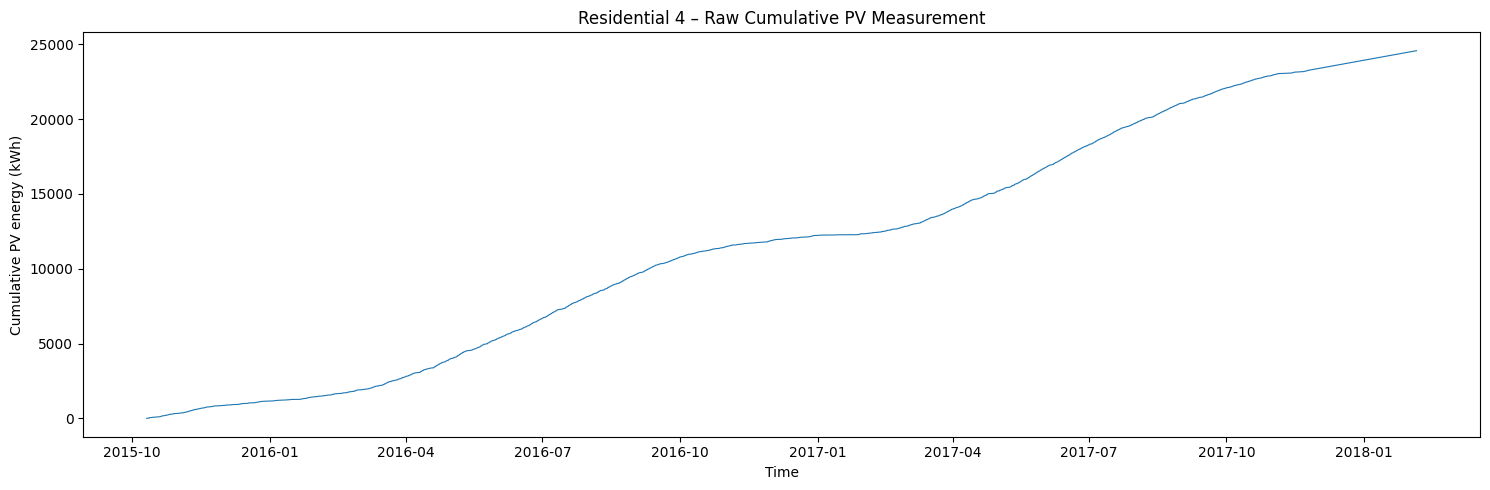

In [8]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["timestamp"],
    df["pv"],
    linewidth=0.8
)

plt.xlabel("Time")
plt.ylabel("Cumulative PV energy (kWh)")
plt.title("Residential 4 – Raw Cumulative PV Measurement")

plt.tight_layout()
plt.show()


The steadily increasing profile above is expected because the raw measurement
is cumulative. It is **not** the PV generation profile that will be used by
the forecasting models.


In [9]:
# Create hourly energy from the cumulative measurements

df["pv_hourly"] = df["pv"].diff()
df["grid_import_hourly"] = df["grid_import"].diff()

print("PV hourly energy:")
print(df["pv_hourly"].describe())

print("\nGrid-import hourly energy:")
print(df["grid_import_hourly"].describe())


PV hourly energy:
count   20359.0000
mean        1.2072
std         2.0404
min         0.0000
25%         0.0000
50%         0.0098
75%         1.5444
max         8.7852
Name: pv_hourly, dtype: float64

Grid-import hourly energy:
count   20359.0000
mean        0.5033
std         0.5521
min         0.0000
25%         0.0703
50%         0.2943
75%         0.7970
max         4.8975
Name: grid_import_hourly, dtype: float64


In [10]:
# Check for negative increments.
# Negative values would indicate a counter reset or another data issue.

for column in ["pv_hourly", "grid_import_hourly"]:
    negative = (df[column] < 0).sum()
    print(f"{column}: {negative} negative increments")


pv_hourly: 0 negative increments
grid_import_hourly: 0 negative increments


In [11]:
# Check the hourly time step

time_step = df["timestamp"].diff()

print(time_step.value_counts().head())
print("\nExpected hourly observations:",
      (time_step == pd.Timedelta(hours=1)).sum())


timestamp
0 days 01:00:00    38453
Name: count, dtype: int64

Expected hourly observations: 38453


## 2. Missing-data analysis

The original dataset contains gaps and an `interpolated` marker. We retain
the raw marker for transparency and first identify the continuous period in
which both primary cumulative measurements are available.

This avoids creating artificial forecasting sequences across missing periods.


In [12]:
energy_columns = [
    "pv",
    "grid_import",
    "grid_export",
    "ev",
    "heat_pump",
    "dishwasher",
    "freezer",
    "refrigerator",
    "washing_machine"
]

missing = (
    df[energy_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    df[energy_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_values": missing,
    "missing_percentage": missing_percentage
})

missing_summary


,missing_values,missing_percentage
refrigerator,27690,72.0081
washing_machine,26196,68.1230
heat_pump,26143,67.9851
dishwasher,25834,67.1816
ev,18166,47.2409
freezer,18166,47.2409
pv,18094,47.0536
grid_import,18094,47.0536
grid_export,18094,47.0536


In [13]:
print("Number of distinct interpolation markers:",
      df["interpolated"].nunique(dropna=True))

print("\nRows with any interpolation marker:",
      df["interpolated"].notna().sum())

print("\nExample markers:")
df.loc[df["interpolated"].notna(), "interpolated"].head(10).tolist()


Number of distinct interpolation markers: 1839

Rows with any interpolation marker: 31797

Example markers:


['DE_KN_residential3_washing_machine',
 'DE_KN_residential3_washing_machine',
 'DE_KN_residential3_washing_machine',
 'DE_KN_residential3_washing_machine',
 'DE_KN_residential3_freezer',
 'DE_KN_residential3_freezer',
 'DE_KN_residential3_freezer',
 'DE_KN_residential3_washing_machine',
 'DE_KN_residential3_washing_machine',
 'DE_KN_residential3_washing_machine']

In [14]:
df["valid_for_forecasting"] = (
    df["pv"].notna() &
    df["grid_import"].notna()
)

print("Valid raw observations:",
      df["valid_for_forecasting"].sum())

print("Invalid raw observations:",
      (~df["valid_for_forecasting"]).sum())


Valid raw observations: 20360
Invalid raw observations: 18094


In [15]:
# Identify continuous valid blocks

df["valid_block"] = (
    df["valid_for_forecasting"]
    != df["valid_for_forecasting"].shift()
).cumsum()

valid_blocks = (
    df[df["valid_for_forecasting"]]
    .groupby("valid_block")
    .agg(
        start=("timestamp", "min"),
        end=("timestamp", "max"),
        observations=("timestamp", "count")
    )
    .sort_values("observations", ascending=False)
)

valid_blocks.head(10)


,start,end,observations
valid_block,,,
2,2015-10-10 16:00:00+00:00,2018-02-04 23:00:00+00:00,20360


In [16]:
largest_block = valid_blocks.iloc[0]

print("Largest continuous valid block")
print("--------------------------------")
print("Start:", largest_block["start"])
print("End:", largest_block["end"])
print("Observations:", largest_block["observations"])


Largest continuous valid block
--------------------------------
Start: 2015-10-10 16:00:00+00:00
End: 2018-02-04 23:00:00+00:00
Observations: 20360


In [17]:
largest_block_id = valid_blocks.index[0]

model_df = df[
    (df["valid_block"] == largest_block_id) &
    (df["valid_for_forecasting"])
].copy()

model_df = model_df.reset_index(drop=True)

# Recalculate hourly energy inside the selected continuous block.
# This ensures that the first observation does not accidentally use a
# cumulative difference from an invalid period.

model_df["pv_hourly"] = model_df["pv"].diff()
model_df["grid_import_hourly"] = model_df["grid_import"].diff()

print("Modelling block shape:", model_df.shape)
print("Start:", model_df["timestamp"].min())
print("End:", model_df["timestamp"].max())


Modelling block shape: (20360, 17)
Start: 2015-10-10 16:00:00+00:00
End: 2018-02-04 23:00:00+00:00


In [18]:
# Remove the first row because its hourly difference is undefined.

model_df = model_df.dropna(
    subset=["pv_hourly", "grid_import_hourly"]
).reset_index(drop=True)

print("Final modelling observations:", len(model_df))
print("Start:", model_df["timestamp"].min())
print("End:", model_df["timestamp"].max())

print("\nTime-step check:")
print(model_df["timestamp"].diff().value_counts().head())


Final modelling observations: 20359
Start: 2015-10-10 17:00:00+00:00
End: 2018-02-04 23:00:00+00:00

Time-step check:
timestamp
0 days 01:00:00    20358
Name: count, dtype: int64


In [19]:
# Confirm that the derived hourly energy values are physically sensible.

hourly_summary = model_df[
    ["pv_hourly", "grid_import_hourly"]
].describe().T

hourly_summary


,count,mean,std,min,25%,50%,75%,max
pv_hourly,20359.0000,1.2072,2.0404,0.0000,0.0000,0.0098,1.5444,8.7852
grid_import_hourly,20359.0000,0.5033,0.5521,0.0000,0.0703,0.2943,0.7970,4.8975


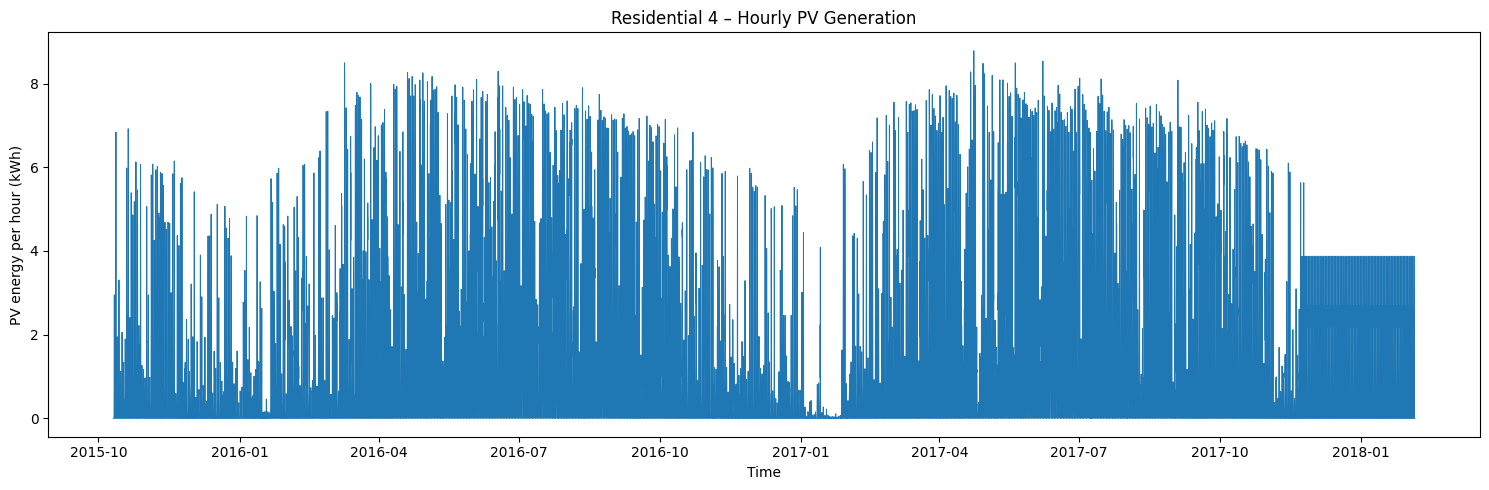

In [20]:
plt.figure(figsize=(15, 5))

plt.plot(
    model_df["timestamp"],
    model_df["pv_hourly"],
    linewidth=0.7
)

plt.xlabel("Time")
plt.ylabel("PV energy per hour (kWh)")
plt.title("Residential 4 – Hourly PV Generation")

plt.tight_layout()
plt.show()


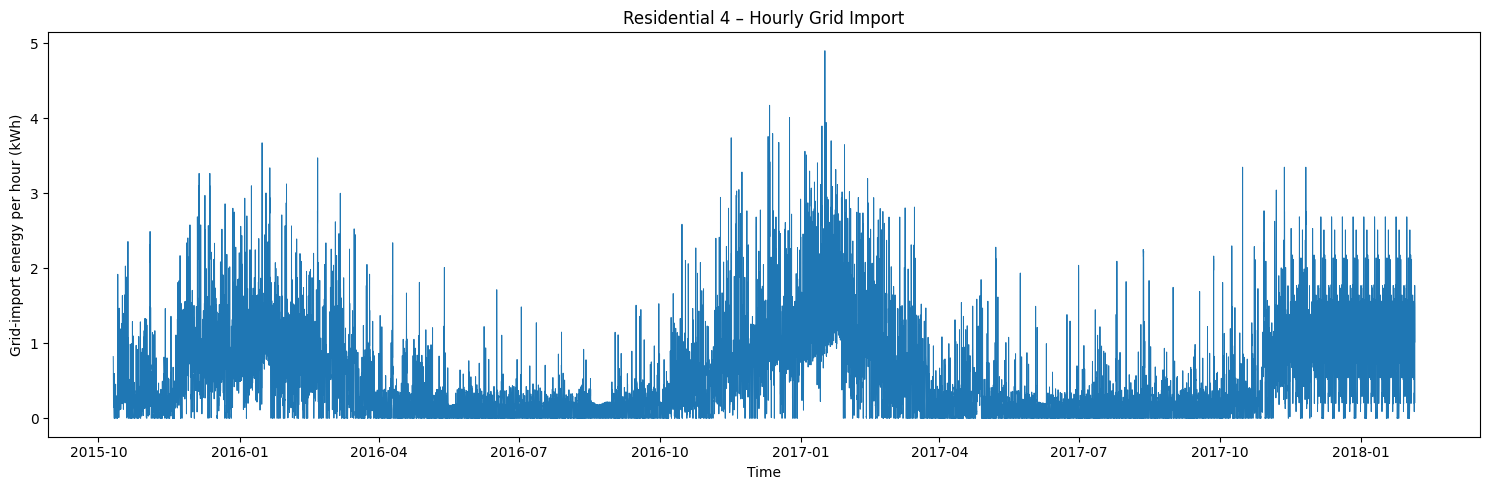

In [21]:
plt.figure(figsize=(15, 5))

plt.plot(
    model_df["timestamp"],
    model_df["grid_import_hourly"],
    linewidth=0.7
)

plt.xlabel("Time")
plt.ylabel("Grid-import energy per hour (kWh)")
plt.title("Residential 4 – Hourly Grid Import")

plt.tight_layout()
plt.show()


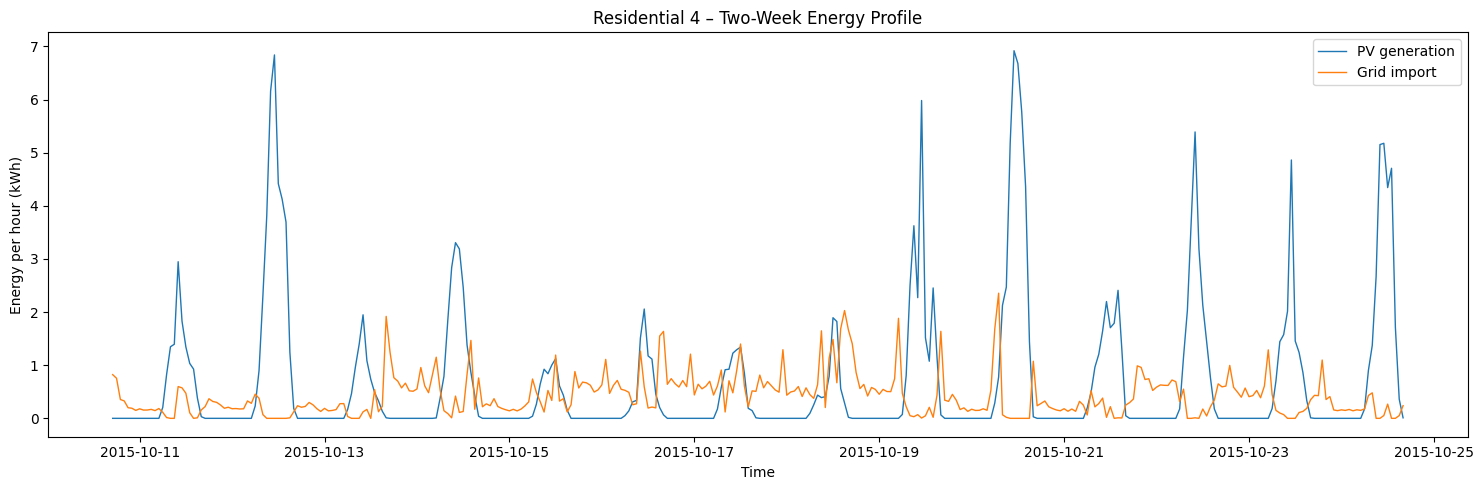

In [22]:
# Show a representative two-week period to make the daily patterns visible.

sample_start = model_df["timestamp"].min()
sample_end = sample_start + pd.Timedelta(days=14)

sample = model_df[
    (model_df["timestamp"] >= sample_start) &
    (model_df["timestamp"] < sample_end)
]

plt.figure(figsize=(15, 5))

plt.plot(
    sample["timestamp"],
    sample["pv_hourly"],
    label="PV generation",
    linewidth=1
)

plt.plot(
    sample["timestamp"],
    sample["grid_import_hourly"],
    label="Grid import",
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Energy per hour (kWh)")
plt.title("Residential 4 – Two-Week Energy Profile")
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Temporal features

model_df["hour"] = model_df["timestamp"].dt.hour
model_df["day_of_week"] = model_df["timestamp"].dt.dayofweek
model_df["month"] = model_df["timestamp"].dt.month

hourly_profile = (
    model_df
    .groupby("hour")[["pv_hourly", "grid_import_hourly"]]
    .mean()
)

hourly_profile


,pv_hourly,grid_import_hourly
hour,,
0,0.0000,0.5105
1,0.0000,0.5071
2,0.0000,0.4985
3,0.0021,0.5016
4,0.0463,0.5032
5,0.1747,0.5531
6,0.5027,0.7002
7,1.2391,0.4504
8,2.2161,0.3334


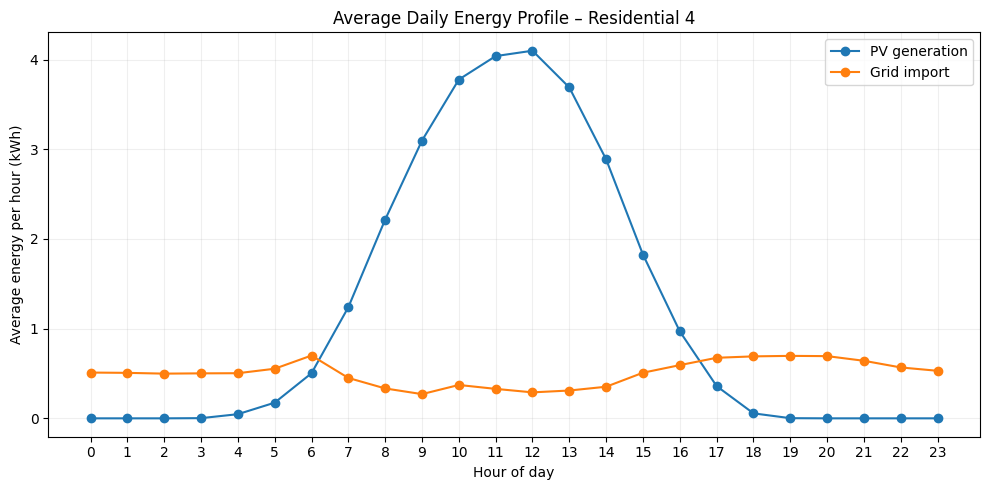

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile["pv_hourly"],
    marker="o",
    label="PV generation"
)

plt.plot(
    hourly_profile.index,
    hourly_profile["grid_import_hourly"],
    marker="o",
    label="Grid import"
)

plt.xlabel("Hour of day")
plt.ylabel("Average energy per hour (kWh)")
plt.title("Average Daily Energy Profile – Residential 4")

plt.xticks(range(24))
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


In [25]:
monthly_profile = (
    model_df
    .groupby("month")[["pv_hourly", "grid_import_hourly"]]
    .mean()
)

monthly_profile


,pv_hourly,grid_import_hourly
month,,
1,0.4329,1.1070
2,0.7005,0.8060
3,1.3772,0.5055
4,1.6620,0.2674
5,1.9115,0.1569
6,2.0350,0.1239
7,1.9658,0.1392
8,1.8567,0.1516
9,1.5434,0.1747


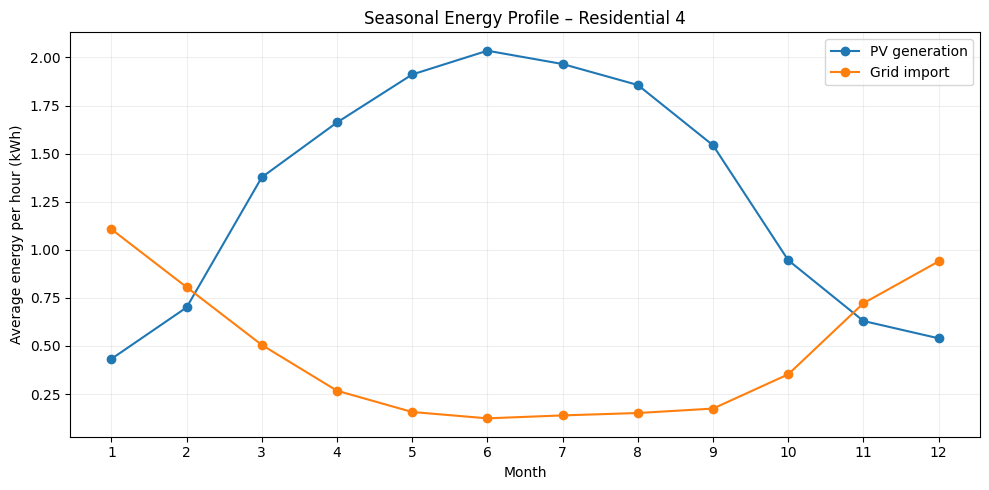

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profile.index,
    monthly_profile["pv_hourly"],
    marker="o",
    label="PV generation"
)

plt.plot(
    monthly_profile.index,
    monthly_profile["grid_import_hourly"],
    marker="o",
    label="Grid import"
)

plt.xlabel("Month")
plt.ylabel("Average energy per hour (kWh)")
plt.title("Seasonal Energy Profile – Residential 4")

plt.xticks(range(1, 13))
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
# Correlation after converting cumulative measurements to hourly energy

correlation_columns = [
    "pv_hourly",
    "grid_import_hourly"
]

correlation_matrix = model_df[correlation_columns].corr()

correlation_matrix


,pv_hourly,grid_import_hourly
pv_hourly,1.0000,-0.4310
grid_import_hourly,-0.4310,1.0000


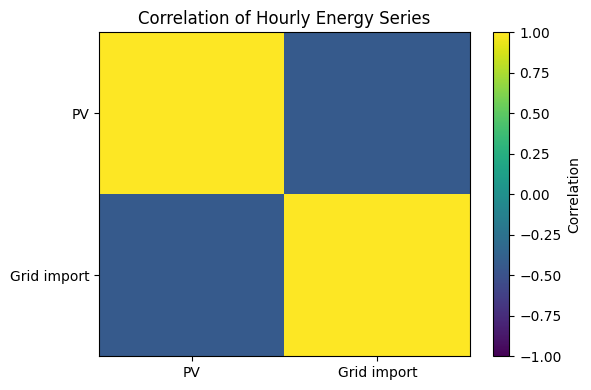

In [28]:
plt.figure(figsize=(6, 4))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    ["PV", "Grid import"]
)

plt.yticks(
    range(len(correlation_columns)),
    ["PV", "Grid import"]
)

plt.title("Correlation of Hourly Energy Series")

plt.tight_layout()
plt.show()


## 3. Prepare the modelling dataset

The final dataset contains:

- `timestamp`
- `pv_hourly` — hourly PV generation in kWh
- `grid_import_hourly` — hourly grid-import energy in kWh
- `grid_export`
- `ev`
- `heat_pump`
- appliance measurements

The forecasting experiments will primarily use `pv_hourly` and
`grid_import_hourly`.


In [29]:
output_columns = [
    "timestamp",
    "pv_hourly",
    "grid_import_hourly",
    "grid_export",
    "ev",
    "heat_pump",
    "dishwasher",
    "freezer",
    "refrigerator",
    "washing_machine"
]

model_output = model_df[output_columns].copy()

OUTPUT_PATH = "/content/residential4_model_data.csv"

model_output.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {model_output.shape}")


Saved: /content/residential4_model_data.csv
Shape: (20359, 10)


In [30]:
print("Final dataset summary:")
print("-----------------------")
print("Observations:", len(model_output))
print("Start:", model_output["timestamp"].min())
print("End:", model_output["timestamp"].max())
print("PV missing:", model_output["pv_hourly"].isna().sum())
print("Grid-import missing:", model_output["grid_import_hourly"].isna().sum())
print("Negative PV values:", (model_output["pv_hourly"] < 0).sum())
print("Negative grid-import values:", (model_output["grid_import_hourly"] < 0).sum())


Final dataset summary:
-----------------------
Observations: 20359
Start: 2015-10-10 17:00:00+00:00
End: 2018-02-04 23:00:00+00:00
PV missing: 0
Grid-import missing: 0
Negative PV values: 0
Negative grid-import values: 0


# Summary

The raw Residential 4 PV and grid-import measurements are cumulative energy
readings. They were therefore converted into hourly energy values by taking
successive differences.

The notebook then:

1. Inspected the original dataset and its time resolution.
2. Examined missing observations and interpolation markers.
3. Identified the longest continuous period containing both PV and grid-import
   measurements.
4. Converted the cumulative measurements into hourly kWh values.
5. Checked for negative increments and hourly time-step consistency.
6. Investigated daily and seasonal patterns.
7. Created the clean modelling dataset for the forecasting experiments.

## Next notebook

`02_lstm_forecasting.ipynb`

The next stage will establish a simple persistence baseline and then train an
LSTM model for time-series forecasting before moving to the Transformer and
transfer-learning experiments.
